In [5]:
# Aula 02 de Inteligencia Artificial - 02/03/2026

In [7]:
# Importando bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [8]:
# Gerar dataset sintetico:

# Geracao de numero aleatorio com seed definida
np.random.seed(23)

# Tamanho amostral
n = 300

# Criacao do dataframe
df = pd.DataFrame({
                               # (media, desvio padrao, tamanho amostral)
    "Matematica":np.random.normal(70, 10, n),  # np.random.normal = valor qualquer
    "Logica":np.random.normal(65, 12, n),
    "Estatistica":np.random.normal(75, 8, n),
    "Frequencia":np.random.randint(50, 100, n)  # Randint = inteiro aleatorio
})

# Exibe o dataframe
print(df)

     Matematica     Logica  Estatistica  Frequencia
0     76.669881  75.233651    63.634028          55
1     70.258131  36.747713    75.324342          69
2     62.223806  66.643184    54.939552          51
3     79.486338  44.399062    84.023988          55
4     77.016718  42.709211    80.465164          83
..          ...        ...          ...         ...
295   64.138867  57.409505    66.190095          94
296   57.731163  57.719213    78.996667          73
297   72.536349  62.578311    85.959607          58
298   67.018934  64.233397    79.436119          61
299   69.776036  75.368493    70.521350          65

[300 rows x 4 columns]


In [9]:
# Criacao da variavel resposta (y) - insercao de coluna no DataFrame
df["nota_final"] = (
    # Pesos - dados para a equacao
    0.4 * df["Matematica"] +
    0.3 * df["Estatistica"] +
    0.2 * df["Logica"] +
    0.1 * df["Frequencia"] +
    np.random.normal(0,5, n)  # Erro amostral
)

In [16]:
# ★ Correlacao de Pearson (interpretar)
print(df.corr())

             Matematica    Logica  Estatistica  Frequencia  nota_final
Matematica     1.000000 -0.052004     0.001240   -0.029958    0.521141
Logica        -0.052004  1.000000     0.090646    0.083399    0.378562
Estatistica    0.001240  0.090646     1.000000   -0.043784    0.366071
Frequencia    -0.029958  0.083399    -0.043784    1.000000    0.194908
nota_final     0.521141  0.378562     0.366071    0.194908    1.000000


In [15]:
# ★ Definindo variaveis explicativas x (features/explicativa) e y (target)
x = df[["Matematica", "Estatistica", "Logica", "Frequencia"]]  # Deve ser numero!
y = df["nota_final"]

# Obs. Ignore variaveis qualitativas e irrelevantes (por agora)

In [11]:
# ★ Construcao do modelo (treinando o modelo de regressao)
model = LinearRegression()
model.fit(x, y)  # Treinar com as variaveis

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# Mostra o intercepto (a0) e os coeficientes (x)
print("\nIntercepto:", model.intercept_)  # y
print("\nCoeficientes:", model.coef_)     # x (fica na ordem definida no df x)

# \Equacao final (a nota final de qualquer aluno): 
#  y = -1,75 + 0,41 * Matematica
#      + 0,33 * Estatistica
#      + 0,19 * Logica
#      + 0,08 * Frequencia


Intercepto: -1.2084940458947386

Coeficientes: [0.37490348 0.35188204 0.19929357 0.08531286]


In [13]:
# Evidenciando previsoes
df["nota_prevista"] = model.predict(x)

print("\nComparacao Real vs Previsto:\n")
print(df[["nota_final", "nota_prevista"]].head(10))


Comparacao Real vs Previsto:

   nota_final  nota_prevista
0   61.545083      69.612773
1   65.664224      64.846977
2   58.022587      59.084183
3   67.355004      71.698397
4   70.517596      71.572226
5   66.500358      63.717952
6   72.062051      65.358209
7   50.966334      59.351337
8   62.375043      60.393763
9   92.451724      77.878830


In [14]:
# Avaliacao do modelo
r2 = r2_score(y, df["nota_prevista"])
print("Acertou:\n", r2, "% das notas em media.")

# r2 eh uma medida que varia de 1 a 0;
# Quanto maior, melhor, dependendo do contexto (neste aqui, eh ok~)

Acertou:
 0.4955001472038294 % das notas em media.


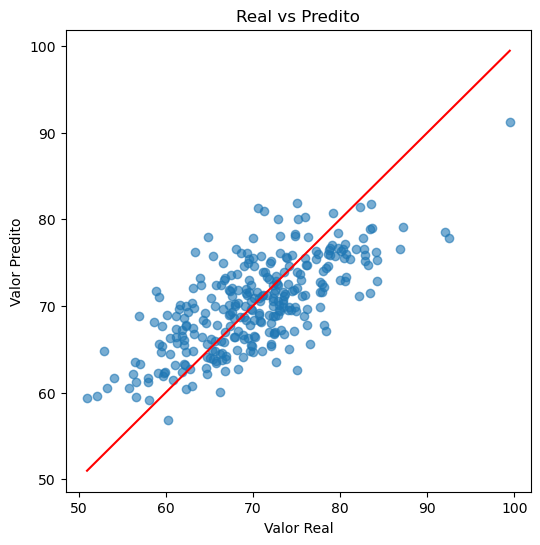

In [16]:
# 8) GRÁFICO REAL VS PREDITO
plt.figure(figsize=(6,6))
plt.scatter(y, df["nota_prevista"], alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.title("Real vs Predito")
plt.show()

In [18]:
# -- Regressao Logitisca - para saber se foi aprovado ou nao --
df["aprovado"] = (df["nota_final"] >= 66).astype(int)  # Variavel binaria

print(df)

     Matematica     Logica  Estatistica  Frequencia  nota_final  \
0     76.669881  75.233651    63.634028          55   61.545083   
1     70.258131  36.747713    75.324342          69   65.664224   
2     62.223806  66.643184    54.939552          51   58.022587   
3     79.486338  44.399062    84.023988          55   67.355004   
4     77.016718  42.709211    80.465164          83   70.517596   
..          ...        ...          ...         ...         ...   
295   64.138867  57.409505    66.190095          94   64.786077   
296   57.731163  57.719213    78.996667          73   65.635319   
297   72.536349  62.578311    85.959607          58   68.130520   
298   67.018934  64.233397    79.436119          61   73.461443   
299   69.776036  75.368493    70.521350          65   73.490136   

     nota_prevista  aprovado  
0        69.612773         0  
1        64.846977         0  
2        59.084183         0  
3        71.698397         1  
4        71.572226         1  
..       

In [21]:
# Variaveis explicativas e variavel resposta
x = df[["Matematica", "Estatistica", "Logica", "Frequencia"]]
y = df["aprovado"]

# Separando amostra em treino e teste (70-30%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 23)

In [23]:
# Criando o modelo de reg. logistica
log_model = LogisticRegression(max_iter = 1000)  # max_iter = maximo de iteracoes com os testes

# Aplicando o modelo
log_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [36]:
# Analisando o y predito (resultado do teste)
y_pred = log_model.predict(x_test)
probs = log_model.predict_proba(x_test)  # Para grafico

# Verifica o y (x eh explicativa)
cm = confusion_matrix(y_test, y_pred)

# -- Matriz de Confusao --
# Amostra (somando tudo da 90 -> os 30% para teste)
print(cm)
# Na vertical: previsto
# Na horizonta: real

# 14  15  --> 14 o modelo dizia que seria aprovado (acerto), e foi, porem, o modelo disse 8 (erro)
# 7   54  --> preveu que 7 seriam reprovados, mas na tabela, 7 foram aprovados (erro); o modelo disse que 54 seriam reprovados, e foram (acerto)

# Acuracia = acertos/total
# 14+54 / 90 (os 30%) = 0,75
# Acuracia = 75%

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

[[14 15]
 [ 7 54]]
Accuracy: 0.7555555555555555


In [38]:
# Teste:
novo_aluno = [[70, 65, 80, 90]]  # notas
prob = log_model.predict_proba(novo_aluno)
print(prob)  # chance de ser reprovado e de ser aprovado em %

[[0.15741675 0.84258325]]


C:\Users\Drummond\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
